In [1]:
import os
import gc
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
GPU Memory: 10.74 GB


In [2]:
PROCESSED_PATH = "D:/Work/Uni/FYP/architext/data/processed"
OUTPUT_PATH = "D:/Work/Uni/FYP/architext/models/resplan_gnn"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load normalization constants
norm_constants = np.load(os.path.join(PROCESSED_PATH, 'norm_constants.npy'), allow_pickle=True).item()
metadata = np.load(os.path.join(PROCESSED_PATH, 'metadata.npy'), allow_pickle=True).item()

NODE_FEATURE_DIM = norm_constants['node_feature_dim']
CONDITION_DIM = norm_constants['condition_dim']
NUM_ROOM_TYPES = len(norm_constants['room_types'])
ROOM_TYPES = norm_constants['room_types']

print(f"Node feature dimension: {NODE_FEATURE_DIM}")
print(f"Condition dimension: {CONDITION_DIM}")
print(f"Room types: {ROOM_TYPES}")
print(f"Total samples: {metadata['total_processed']}")

# Training configuration
CONFIG = {
    'batch_size': 16,  # Reduced for RTX 3080
    'num_epochs': 300,
    'learning_rate': 1e-3,
    
    # GNN architecture
    'hidden_dim': 256,
    'num_layers': 4,
    'dropout': 0.1,
    
    # Max nodes (for padding)
    'max_nodes': 30,
    
    # Loss weights
    'adj_loss_weight': 1.0,
    'feat_loss_weight': 0.5,
    
    # Validation
    'val_split': 0.1,
    'save_every': 10,
}

print("\nTraining configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Node feature dimension: 16
Condition dimension: 18
Room types: ['wall', 'bedroom', 'bathroom', 'living', 'kitchen', 'balcony', 'storage', 'parking', 'garden', 'pool', 'stair', 'veranda', 'inner']
Total samples: 16994

Training configuration:
  batch_size: 16
  num_epochs: 300
  learning_rate: 0.001
  hidden_dim: 256
  num_layers: 4
  dropout: 0.1
  max_nodes: 30
  adj_loss_weight: 1.0
  feat_loss_weight: 0.5
  val_split: 0.1
  save_every: 10


In [3]:
class FloorplanGraphDataset(Dataset):
    """Dataset for loading preprocessed graph data."""
    
    def __init__(self, processed_path, indices=None, max_nodes=30):
        self.processed_path = processed_path
        self.batch_dir = os.path.join(processed_path, 'batches')
        self.max_nodes = max_nodes
        
        # Load metadata
        metadata = np.load(os.path.join(processed_path, 'metadata.npy'), allow_pickle=True).item()
        self.num_batches = metadata['num_batches']
        
        # Build sample list
        self.samples = []
        
        for batch_idx in range(self.num_batches):
            batch_file = os.path.join(self.batch_dir, f'batch_{batch_idx:04d}.npz')
            graph_file = os.path.join(self.batch_dir, f'graphs_{batch_idx:04d}.pkl')
            
            if os.path.exists(batch_file) and os.path.exists(graph_file):
                data = np.load(batch_file)
                num_samples = len(data['conditions'])
                data.close()
                
                for i in range(num_samples):
                    self.samples.append((batch_idx, i))
        
        # Filter by indices if specified
        if indices is not None:
            self.samples = [self.samples[i] for i in indices]
        
        # Cache
        self._cached_batch_idx = None
        self._cached_batch_data = None
        self._cached_graph_data = None
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        batch_idx, sample_idx = self.samples[idx]
        
        # Load batch if not cached
        if self._cached_batch_idx != batch_idx:
            if self._cached_batch_data is not None:
                del self._cached_batch_data
                del self._cached_graph_data
            
            batch_file = os.path.join(self.batch_dir, f'batch_{batch_idx:04d}.npz')
            graph_file = os.path.join(self.batch_dir, f'graphs_{batch_idx:04d}.pkl')
            
            self._cached_batch_data = np.load(batch_file)
            with open(graph_file, 'rb') as f:
                self._cached_graph_data = pickle.load(f)
            
            self._cached_batch_idx = batch_idx
        
        # Get data
        condition = self._cached_batch_data['conditions'][sample_idx]
        X = self._cached_graph_data['X'][sample_idx]
        A = self._cached_graph_data['A'][sample_idx]
        
        # Pad to max_nodes
        num_nodes = X.shape[0]
        
        X_padded = np.zeros((self.max_nodes, X.shape[1]), dtype=np.float32)
        A_padded = np.zeros((self.max_nodes, self.max_nodes), dtype=np.float32)
        mask = np.zeros(self.max_nodes, dtype=np.float32)
        
        if num_nodes > 0:
            n = min(num_nodes, self.max_nodes)
            X_padded[:n] = X[:n]
            A_padded[:n, :n] = A[:n, :n]
            mask[:n] = 1.0
        
        return {
            'condition': torch.from_numpy(condition),
            'X': torch.from_numpy(X_padded),
            'A': torch.from_numpy(A_padded),
            'mask': torch.from_numpy(mask),
            'num_nodes': num_nodes
        }


def collate_fn(batch):
    """Custom collate function for graph batches."""
    return {
        'condition': torch.stack([b['condition'] for b in batch]),
        'X': torch.stack([b['X'] for b in batch]),
        'A': torch.stack([b['A'] for b in batch]),
        'mask': torch.stack([b['mask'] for b in batch]),
        'num_nodes': [b['num_nodes'] for b in batch]
    }


# Create datasets
print("Creating datasets...")

# Full dataset
full_dataset = FloorplanGraphDataset(PROCESSED_PATH, max_nodes=CONFIG['max_nodes'])
total_samples = len(full_dataset)

# Split indices
indices = np.random.permutation(total_samples)
val_size = int(total_samples * CONFIG['val_split'])
train_indices = indices[val_size:]
val_indices = indices[:val_size]

train_dataset = FloorplanGraphDataset(PROCESSED_PATH, train_indices, CONFIG['max_nodes'])
val_dataset = FloorplanGraphDataset(PROCESSED_PATH, val_indices, CONFIG['max_nodes'])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,  # Windows: must be 0 in Jupyter
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,  # Windows: must be 0 in Jupyter
    pin_memory=True,
    collate_fn=collate_fn
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Creating datasets...
Training samples: 15295
Validation samples: 1699
Training batches: 955
Validation batches: 107


In [4]:
class GraphAttention(nn.Module):
    """Graph attention layer."""
    
    def __init__(self, in_dim, out_dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = out_dim // num_heads
        
        self.W_q = nn.Linear(in_dim, out_dim)
        self.W_k = nn.Linear(in_dim, out_dim)
        self.W_v = nn.Linear(in_dim, out_dim)
        self.W_o = nn.Linear(out_dim, out_dim)
        
        self.scale = self.head_dim ** -0.5
    
    def forward(self, x, mask=None):
        B, N, _ = x.shape
        
        # Multi-head attention
        Q = self.W_q(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        
        # Apply mask
        if mask is not None:
            mask_2d = mask.unsqueeze(1).unsqueeze(2) * mask.unsqueeze(1).unsqueeze(3)
            # Use -1e4 instead of -1e9 for float16 compatibility
            scores = scores.masked_fill(mask_2d == 0, -1e4)
        
        attn = F.softmax(scores, dim=-1)
        
        # Apply attention to values
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, N, -1)
        
        return self.W_o(out)


class GNNLayer(nn.Module):
    """Single GNN layer with attention and feed-forward."""
    
    def __init__(self, hidden_dim, num_heads=4, dropout=0.1):
        super().__init__()
        
        self.attention = GraphAttention(hidden_dim, hidden_dim, num_heads)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Self-attention with residual
        x = x + self.dropout(self.attention(self.norm1(x), mask))
        
        # Feed-forward with residual
        x = x + self.ff(self.norm2(x))
        
        return x


class StructuralGNN(nn.Module):
    """
    GNN for predicting structural features from conditioning.
    
    Takes conditioning vector and predicts:
    - Number of nodes (rooms)
    - Node features (room types, positions)
    - Adjacency matrix (room connectivity)
    """
    
    def __init__(self, condition_dim, node_feature_dim, hidden_dim=256, 
                 num_layers=4, max_nodes=30, dropout=0.1):
        super().__init__()
        
        self.max_nodes = max_nodes
        self.hidden_dim = hidden_dim
        self.node_feature_dim = node_feature_dim
        
        # Condition encoder
        self.condition_encoder = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        
        # Node count predictor
        self.num_nodes_predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, max_nodes)  # Predict distribution over node counts
        )
        
        # Initial node embeddings (learnable)
        self.node_embedding = nn.Parameter(torch.randn(1, max_nodes, hidden_dim) * 0.02)
        
        # Condition to node projection
        self.cond_to_nodes = nn.Linear(hidden_dim, hidden_dim)
        
        # GNN layers
        self.gnn_layers = nn.ModuleList([
            GNNLayer(hidden_dim, num_heads=4, dropout=dropout)
            for _ in range(num_layers)
        ])
        
        # Output heads
        # Node features
        self.node_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, node_feature_dim)
        )
        
        # Adjacency prediction (edge predictor)
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, condition, mask=None):
        B = condition.shape[0]
        
        # Encode condition
        cond_emb = self.condition_encoder(condition)  # [B, hidden_dim]
        
        # Predict number of nodes
        num_nodes_logits = self.num_nodes_predictor(cond_emb)  # [B, max_nodes]
        
        # Initialize node embeddings
        nodes = self.node_embedding.expand(B, -1, -1)  # [B, max_nodes, hidden_dim]
        
        # Add condition information to nodes
        cond_proj = self.cond_to_nodes(cond_emb).unsqueeze(1)  # [B, 1, hidden_dim]
        nodes = nodes + cond_proj
        
        # GNN message passing
        for layer in self.gnn_layers:
            nodes = layer(nodes, mask)
        
        # Predict node features
        node_features = self.node_head(nodes)  # [B, max_nodes, node_feature_dim]
        
        # Apply softmax to room type one-hot portion
        num_room_types = node_features.shape[-1] - 3  # Subtract area + centroid_x + centroid_y
        room_type_logits = node_features[..., :num_room_types]
        other_features = node_features[..., num_room_types:]
        
        # Normalize room types (soft one-hot)
        room_types_pred = F.softmax(room_type_logits, dim=-1)
        # Sigmoid for other features (bounded 0-1)
        other_pred = torch.sigmoid(other_features)
        
        node_features_pred = torch.cat([room_types_pred, other_pred], dim=-1)
        
        # Predict adjacency matrix
        # Compute pairwise edge scores
        nodes_i = nodes.unsqueeze(2).expand(-1, -1, self.max_nodes, -1)  # [B, N, N, hidden]
        nodes_j = nodes.unsqueeze(1).expand(-1, self.max_nodes, -1, -1)  # [B, N, N, hidden]
        edge_features = torch.cat([nodes_i, nodes_j], dim=-1)  # [B, N, N, hidden*2]
        
        adj_logits = self.edge_head(edge_features).squeeze(-1)  # [B, N, N]
        
        # Make symmetric (keep as logits, don't apply sigmoid)
        adj_logits = (adj_logits + adj_logits.transpose(-1, -2)) / 2
        
        return {
            'node_features': node_features_pred,
            'adjacency_logits': adj_logits,  # Return logits, not probabilities
            'num_nodes_logits': num_nodes_logits
        }


# Create model
model = StructuralGNN(
    condition_dim=CONDITION_DIM,
    node_feature_dim=NODE_FEATURE_DIM,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    max_nodes=CONFIG['max_nodes'],
    dropout=CONFIG['dropout']
).to(DEVICE)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {num_params:,}")


Model parameters: 3,542,447


In [5]:
def gnn_loss(pred, target, mask, adj_weight=1.0, feat_weight=0.5):
    """
    Compute GNN training loss.
    
    Args:
        pred: Dictionary with 'node_features', 'adjacency', 'num_nodes_logits'
        target: Dictionary with 'X', 'A', 'mask', 'num_nodes'
        mask: Node validity mask
        adj_weight: Weight for adjacency loss
        feat_weight: Weight for feature loss
    
    Returns:
        total_loss, loss_dict
    """
    # Expand mask for pairwise operations
    mask_2d = mask.unsqueeze(1) * mask.unsqueeze(2)  # [B, N, N]
    
    # Adjacency loss (binary cross-entropy with logits - safe for autocast)
    adj_logits = pred['adjacency_logits']
    adj_target = target['A']
    
    # Focal loss for adjacency (handle class imbalance)
    gamma = 2.0
    alpha = 0.25
    
    # Use BCE with logits (autocast-safe)
    bce = F.binary_cross_entropy_with_logits(adj_logits, adj_target, reduction='none')
    
    # Compute focal weight
    adj_probs = torch.sigmoid(adj_logits)
    pt = torch.where(adj_target == 1, adj_probs, 1 - adj_probs)
    focal_weight = alpha * (1 - pt) ** gamma
    adj_loss = (focal_weight * bce * mask_2d).sum() / (mask_2d.sum() + 1e-8)
    
    # Node feature loss
    feat_pred = pred['node_features']
    feat_target = target['X']
    
    # Room type loss (cross-entropy)
    num_room_types = NUM_ROOM_TYPES
    room_type_pred = feat_pred[..., :num_room_types]
    room_type_target = feat_target[..., :num_room_types]
    
    # Use soft cross-entropy
    room_type_loss = -(room_type_target * torch.log(room_type_pred + 1e-8)).sum(dim=-1)
    room_type_loss = (room_type_loss * mask).sum() / (mask.sum() + 1e-8)
    
    # Other features loss (MSE)
    other_pred = feat_pred[..., num_room_types:]
    other_target = feat_target[..., num_room_types:]
    other_loss = F.mse_loss(other_pred, other_target, reduction='none')
    other_loss = (other_loss.mean(dim=-1) * mask).sum() / (mask.sum() + 1e-8)
    
    feat_loss = room_type_loss + other_loss
    
    # Number of nodes loss
    # Convert num_nodes to one-hot targets
    num_nodes_target = torch.zeros_like(pred['num_nodes_logits'])
    for i, n in enumerate(target['num_nodes']):
        if n > 0 and n <= CONFIG['max_nodes']:
            num_nodes_target[i, n-1] = 1.0
        elif n > CONFIG['max_nodes']:
            num_nodes_target[i, -1] = 1.0
    
    num_nodes_loss = F.cross_entropy(
        pred['num_nodes_logits'], 
        num_nodes_target.argmax(dim=-1)
    )
    
    # Total loss
    total_loss = adj_weight * adj_loss + feat_weight * feat_loss + 0.1 * num_nodes_loss
    
    return total_loss, {
        'total': total_loss.item(),
        'adjacency': adj_loss.item(),
        'feature': feat_loss.item(),
        'num_nodes': num_nodes_loss.item()
    }


def compute_adjacency_f1(pred_adj_logits, target_adj, mask, threshold=0.5):
    """Compute F1 score for adjacency prediction."""
    # Apply sigmoid to logits
    pred_adj = torch.sigmoid(pred_adj_logits)
    
    # Threshold predictions
    pred_binary = (pred_adj > threshold).float()
    
    # Flatten and apply mask
    mask_2d = mask.unsqueeze(1) * mask.unsqueeze(2)
    
    pred_flat = pred_binary[mask_2d > 0].cpu().numpy()
    target_flat = target_adj[mask_2d > 0].cpu().numpy()
    
    if len(pred_flat) == 0:
        return 0.0, 0.0, 0.0
    
    f1 = f1_score(target_flat, pred_flat, zero_division=0)
    precision = precision_score(target_flat, pred_flat, zero_division=0)
    recall = recall_score(target_flat, pred_flat, zero_division=0)
    
    return f1, precision, recall


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6
)

# Mixed precision scaler
scaler = torch.amp.GradScaler('cuda')

# Training history
history = {
    'train_loss': [],
    'train_adj_loss': [],
    'train_feat_loss': [],
    'val_loss': [],
    'val_adj_loss': [],
    'val_feat_loss': [],
    'val_f1': [],
    'val_precision': [],
    'val_recall': [],
    'lr': []
}

# Best model tracking
best_val_f1 = 0.0

print("Starting training...")
print("="*60)

# Auto-resume from latest checkpoint
import glob

checkpoints = sorted(glob.glob(os.path.join(OUTPUT_PATH, 'gnn_epoch_*.pt')))
start_epoch = 0
if checkpoints:
    latest = checkpoints[-1]
    ckpt = torch.load(latest, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch']
    print(f"Resumed from: {latest} (epoch {start_epoch})")
else:
    print("No checkpoint found — starting from scratch")

for epoch in range(start_epoch, CONFIG['num_epochs']):
#for epoch in range(CONFIG['num_epochs']):
    # Training
    model.train()
    train_losses = {'total': 0, 'adjacency': 0, 'feature': 0}
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    for batch in pbar:
        # Move to device
        condition = batch['condition'].to(DEVICE)
        X = batch['X'].to(DEVICE)
        A = batch['A'].to(DEVICE)
        mask = batch['mask'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass
        with torch.amp.autocast('cuda'):
            pred = model(condition, mask)
            loss, loss_dict = gnn_loss(
                pred, 
                {'X': X, 'A': A, 'mask': mask, 'num_nodes': batch['num_nodes']},
                mask,
                adj_weight=CONFIG['adj_loss_weight'],
                feat_weight=CONFIG['feat_loss_weight']
            )
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Track losses
        train_losses['total'] += loss_dict['total']
        train_losses['adjacency'] += loss_dict['adjacency']
        train_losses['feature'] += loss_dict['feature']
        
        pbar.set_postfix({
            'loss': f"{loss_dict['total']:.4f}",
            'adj': f"{loss_dict['adjacency']:.4f}",
            'feat': f"{loss_dict['feature']:.4f}"
        })
    
    # Average training losses
    num_batches = len(train_loader)
    train_losses = {k: v / num_batches for k, v in train_losses.items()}
    
    # Validation
    model.eval()
    val_losses = {'total': 0, 'adjacency': 0, 'feature': 0}
    val_f1_scores = []
    val_precision_scores = []
    val_recall_scores = []
    
    with torch.no_grad():
        for batch in val_loader:
            condition = batch['condition'].to(DEVICE)
            X = batch['X'].to(DEVICE)
            A = batch['A'].to(DEVICE)
            mask = batch['mask'].to(DEVICE)
            
            with torch.amp.autocast('cuda'):
                pred = model(condition, mask)
                loss, loss_dict = gnn_loss(
                    pred,
                    {'X': X, 'A': A, 'mask': mask, 'num_nodes': batch['num_nodes']},
                    mask,
                    adj_weight=CONFIG['adj_loss_weight'],
                    feat_weight=CONFIG['feat_loss_weight']
                )
            
            val_losses['total'] += loss_dict['total']
            val_losses['adjacency'] += loss_dict['adjacency']
            val_losses['feature'] += loss_dict['feature']
            
            # Compute F1 score
            f1, prec, rec = compute_adjacency_f1(pred['adjacency_logits'], A, mask)
            val_f1_scores.append(f1)
            val_precision_scores.append(prec)
            val_recall_scores.append(rec)
    
    # Average validation metrics
    num_val_batches = len(val_loader)
    val_losses = {k: v / num_val_batches for k, v in val_losses.items()}
    val_f1 = np.mean(val_f1_scores)
    val_precision = np.mean(val_precision_scores)
    val_recall = np.mean(val_recall_scores)
    
    # Update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Record history
    history['train_loss'].append(train_losses['total'])
    history['train_adj_loss'].append(train_losses['adjacency'])
    history['train_feat_loss'].append(train_losses['feature'])
    history['val_loss'].append(val_losses['total'])
    history['val_adj_loss'].append(val_losses['adjacency'])
    history['val_feat_loss'].append(val_losses['feature'])
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")
    print(f"  Train - Loss: {train_losses['total']:.4f}, Adj: {train_losses['adjacency']:.4f}, Feat: {train_losses['feature']:.4f}")
    print(f"  Val   - Loss: {val_losses['total']:.4f}, Adj: {val_losses['adjacency']:.4f}, Feat: {val_losses['feature']:.4f}")
    print(f"  Metrics - F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")
    print(f"  LR: {current_lr:.6f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'config': CONFIG
        }, os.path.join(OUTPUT_PATH, 'gnn_best.pt'))
        print(f"  ✓ Saved best model (F1: {val_f1:.4f})")
    
    # Save checkpoint
    if (epoch + 1) % CONFIG['save_every'] == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'config': CONFIG
        }, os.path.join(OUTPUT_PATH, f'gnn_epoch_{epoch+1:03d}.pt'))
    
    # Memory cleanup
    gc.collect()
    torch.cuda.empty_cache()

# Save final model
torch.save({
    'epoch': CONFIG['num_epochs'],
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': CONFIG
}, os.path.join(OUTPUT_PATH, 'gnn_final.pt'))

print("\n" + "="*60)
print("Training complete!")

Starting training...
Resumed from: D:/Work/Uni/FYP/architext/models/resplan_gnn\gnn_epoch_030.pt (epoch 29)


Epoch 30/300: 100%|████████████| 955/955 [00:23<00:00, 40.52it/s, loss=0.0549, adj=0.0105, feat=0.0880]



Epoch 30/300
  Train - Loss: 0.0778, Adj: 0.0112, Feat: 0.1165
  Val   - Loss: 0.0757, Adj: 0.0111, Feat: 0.1109
  Metrics - F1: 0.6228, Precision: 0.9749, Recall: 0.4589
  LR: 0.000976
  ✓ Saved best model (F1: 0.6228)


Epoch 31/300: 100%|████████████| 955/955 [00:23<00:00, 40.32it/s, loss=0.0830, adj=0.0100, feat=0.1410]



Epoch 31/300
  Train - Loss: 0.0767, Adj: 0.0113, Feat: 0.1190
  Val   - Loss: 0.0785, Adj: 0.0113, Feat: 0.1120
  Metrics - F1: 0.6365, Precision: 0.9181, Recall: 0.4885
  LR: 0.000975
  ✓ Saved best model (F1: 0.6365)


...


Epoch 298/300
  Train - Loss: 0.0560, Adj: 0.0103, Feat: 0.0878
  Val   - Loss: 0.0784, Adj: 0.0111, Feat: 0.1104
  Metrics - F1: 0.6650, Precision: 0.8764, Recall: 0.5376
  LR: 0.000026


Epoch 299/300: 100%|███████████| 955/955 [00:23<00:00, 41.25it/s, loss=0.0869, adj=0.0125, feat=0.1487]



Epoch 299/300
  Train - Loss: 0.0560, Adj: 0.0102, Feat: 0.0878
  Val   - Loss: 0.0785, Adj: 0.0111, Feat: 0.1104
  Metrics - F1: 0.6654, Precision: 0.8768, Recall: 0.5380
  LR: 0.000025


Epoch 300/300: 100%|███████████| 955/955 [00:23<00:00, 41.46it/s, loss=0.0596, adj=0.0111, feat=0.0970]



Epoch 300/300
  Train - Loss: 0.0560, Adj: 0.0102, Feat: 0.0878
  Val   - Loss: 0.0783, Adj: 0.0110, Feat: 0.1104
  Metrics - F1: 0.6663, Precision: 0.8770, Recall: 0.5391
  LR: 0.000023

Training complete!


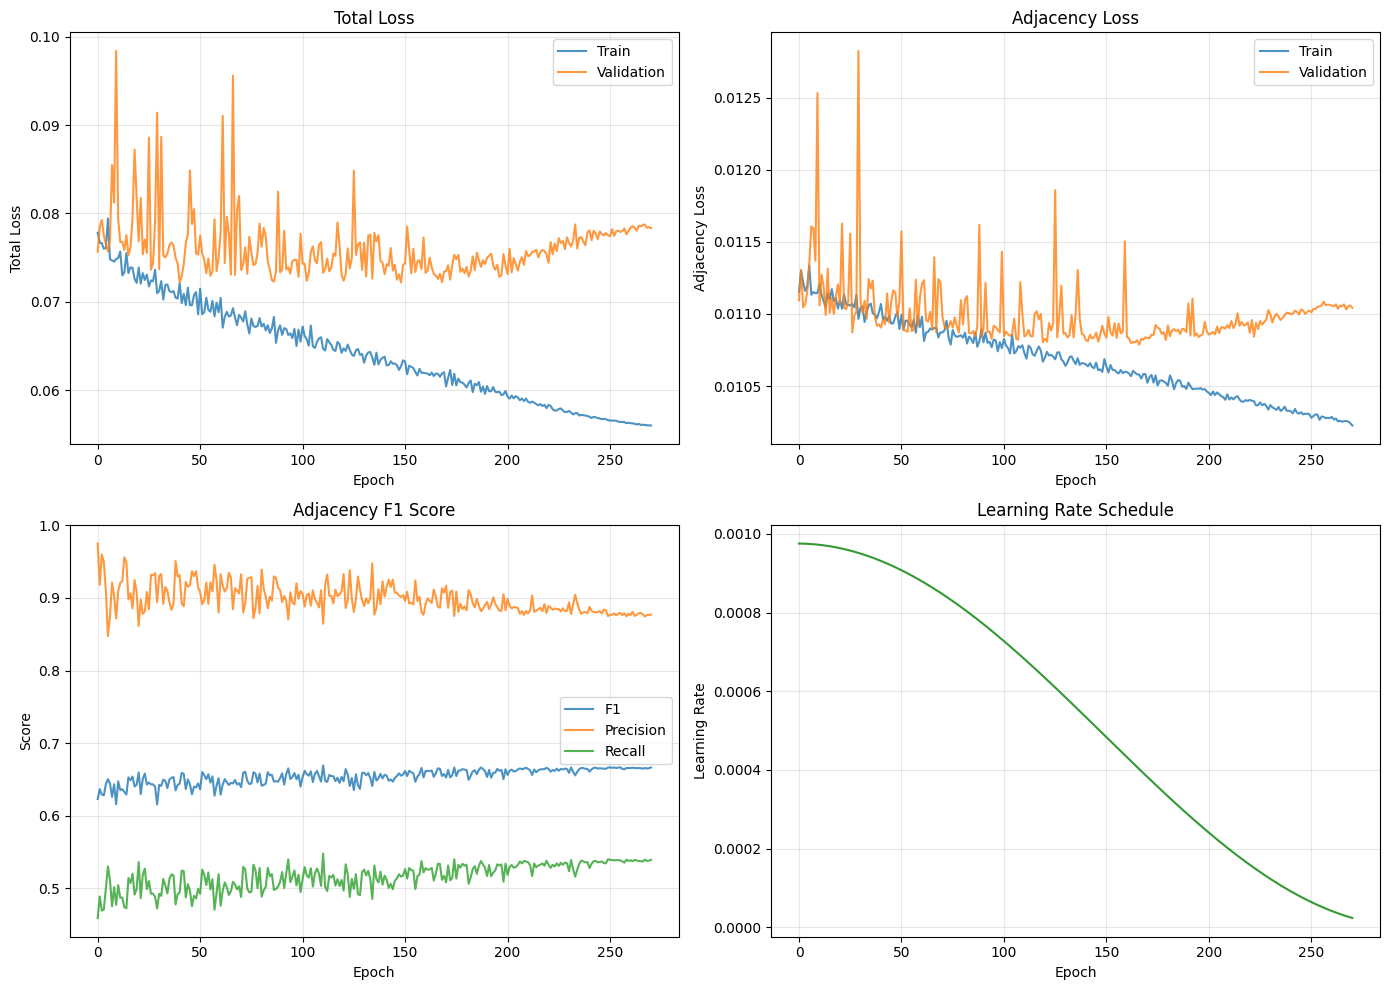

In [7]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train', alpha=0.8)
ax.plot(history['val_loss'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Adjacency loss
ax = axes[0, 1]
ax.plot(history['train_adj_loss'], label='Train', alpha=0.8)
ax.plot(history['val_adj_loss'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Adjacency Loss')
ax.set_title('Adjacency Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# F1 Score
ax = axes[1, 0]
ax.plot(history['val_f1'], label='F1', alpha=0.8)
ax.plot(history['val_precision'], label='Precision', alpha=0.8)
ax.plot(history['val_recall'], label='Recall', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Adjacency F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[1, 1]
ax.plot(history['lr'], color='green', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_curves.png'), dpi=150)
plt.show()



PREDICTION VISUALIZATION


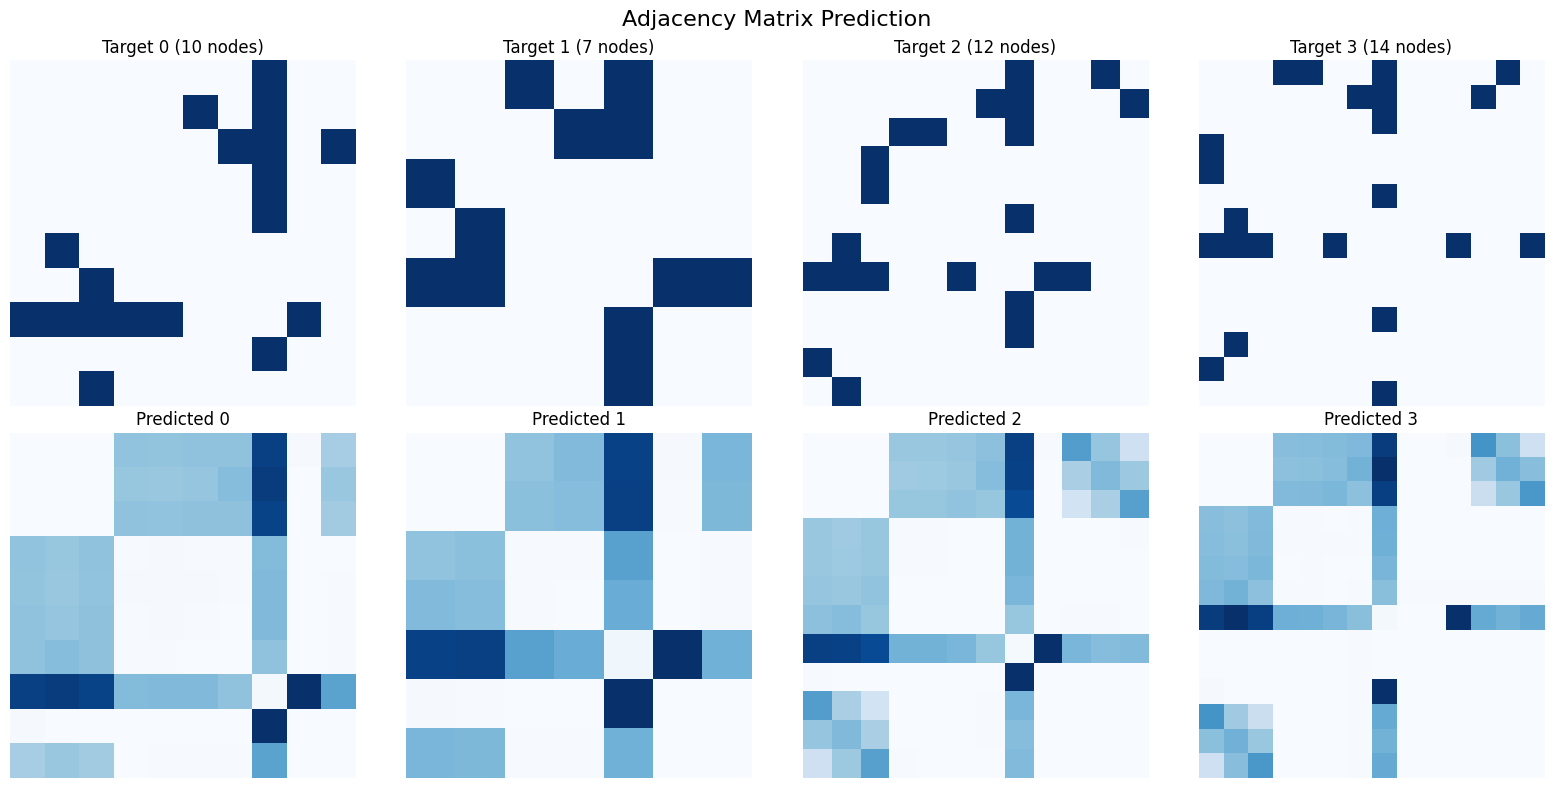

In [9]:
print("\n" + "="*60)
print("PREDICTION VISUALIZATION")
print("="*60)

# Load best model
checkpoint = torch.load(os.path.join(OUTPUT_PATH, 'gnn_best.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get sample batch
sample_batch = next(iter(val_loader))
condition = sample_batch['condition'][:4].to(DEVICE)
X_target = sample_batch['X'][:4].to(DEVICE)
A_target = sample_batch['A'][:4].to(DEVICE)
mask = sample_batch['mask'][:4].to(DEVICE)

# Predict
with torch.no_grad():
    pred = model(condition, mask)

# Visualize adjacency matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Target adjacency
    ax = axes[0, i]
    n = int(mask[i].sum().item())
    target_adj = A_target[i, :n, :n].cpu().numpy()
    ax.imshow(target_adj, cmap='Blues')
    ax.set_title(f'Target {i} ({n} nodes)')
    ax.axis('off')
    
    # Predicted adjacency (apply sigmoid to logits)
    ax = axes[1, i]
    pred_adj = torch.sigmoid(pred['adjacency_logits'][i, :n, :n]).cpu().numpy()
    ax.imshow(pred_adj, cmap='Blues')
    ax.set_title(f'Predicted {i}')
    ax.axis('off')

plt.suptitle('Adjacency Matrix Prediction', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'adjacency_prediction.png'), dpi=150)
plt.show()


ROOM TYPE PREDICTION ANALYSIS


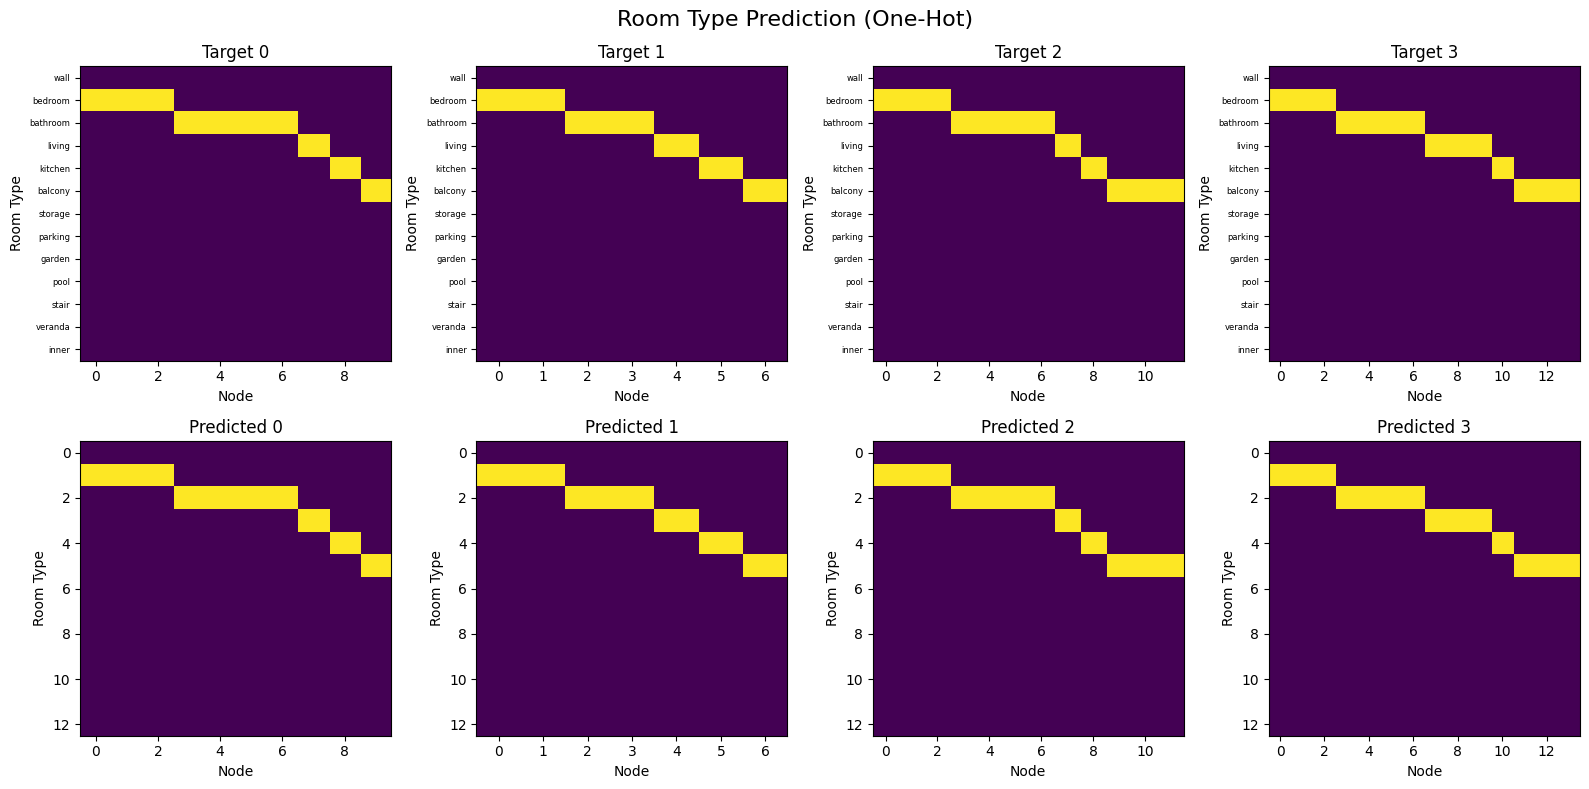

In [10]:
print("\n" + "="*60)
print("ROOM TYPE PREDICTION ANALYSIS")
print("="*60)

# Analyze room type predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    n = int(mask[i].sum().item())
    
    # Target room types
    ax = axes[0, i]
    target_types = X_target[i, :n, :NUM_ROOM_TYPES].cpu().numpy()
    ax.imshow(target_types.T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Node')
    ax.set_ylabel('Room Type')
    ax.set_title(f'Target {i}')
    
    # Predicted room types
    ax = axes[1, i]
    pred_types = pred['node_features'][i, :n, :NUM_ROOM_TYPES].cpu().numpy()
    ax.imshow(pred_types.T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Node')
    ax.set_ylabel('Room Type')
    ax.set_title(f'Predicted {i}')

# Add room type labels
for ax in axes[0, :]:
    ax.set_yticks(range(NUM_ROOM_TYPES))
    ax.set_yticklabels(ROOM_TYPES, fontsize=6)

plt.suptitle('Room Type Prediction (One-Hot)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'room_type_prediction.png'), dpi=150)
plt.show()

In [11]:
print("\n" + "="*60)
print("GNN TRAINING SUMMARY")
print("="*60)

print(f"\nBest validation F1: {best_val_f1:.4f}")
print(f"Final validation precision: {history['val_precision'][-1]:.4f}")
print(f"Final validation recall: {history['val_recall'][-1]:.4f}")

# Storage summary
total_size = 0
for f in os.listdir(OUTPUT_PATH):
    filepath = os.path.join(OUTPUT_PATH, f)
    if os.path.isfile(filepath):
        total_size += os.path.getsize(filepath)

print(f"\nStorage used: {total_size / 1e6:.1f} MB")

print("\nOutput files:")
for f in sorted(os.listdir(OUTPUT_PATH)):
    filepath = os.path.join(OUTPUT_PATH, f)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath) / 1e6
        print(f"  {f}: {size:.1f} MB")

print("\n" + "="*60)
print("GNN Training Complete - Ready for Diffusion Training!")
print("="*60)



GNN TRAINING SUMMARY

Best validation F1: 0.6691
Final validation precision: 0.8770
Final validation recall: 0.5391

Storage used: 1365.5 MB

Output files:
  adjacency_prediction.png: 0.0 MB
  gnn_best.pt: 42.6 MB
  gnn_epoch_010.pt: 42.6 MB
  gnn_epoch_020.pt: 42.6 MB
  gnn_epoch_030.pt: 42.6 MB
  gnn_epoch_040.pt: 42.6 MB
  gnn_epoch_050.pt: 42.6 MB
  gnn_epoch_060.pt: 42.6 MB
  gnn_epoch_070.pt: 42.6 MB
  gnn_epoch_080.pt: 42.6 MB
  gnn_epoch_090.pt: 42.6 MB
  gnn_epoch_100.pt: 42.6 MB
  gnn_epoch_110.pt: 42.6 MB
  gnn_epoch_120.pt: 42.6 MB
  gnn_epoch_130.pt: 42.6 MB
  gnn_epoch_140.pt: 42.6 MB
  gnn_epoch_150.pt: 42.6 MB
  gnn_epoch_160.pt: 42.7 MB
  gnn_epoch_170.pt: 42.7 MB
  gnn_epoch_180.pt: 42.7 MB
  gnn_epoch_190.pt: 42.7 MB
  gnn_epoch_200.pt: 42.7 MB
  gnn_epoch_210.pt: 42.7 MB
  gnn_epoch_220.pt: 42.7 MB
  gnn_epoch_230.pt: 42.7 MB
  gnn_epoch_240.pt: 42.7 MB
  gnn_epoch_250.pt: 42.7 MB
  gnn_epoch_260.pt: 42.7 MB
  gnn_epoch_270.pt: 42.7 MB
  gnn_epoch_280.pt: 42.7 MB
 